# Brazilian E-Commerce Analytics: Olist

## Business objective

This project analyzes the Brazilian Olist marketplace to identify growth opportunities in sales, customer retention, and delivery quality.

**Main questions**

1. How are orders and GMV changing over time?
2. Which product categories generate the most GMV?
3. How often do customers return after their first purchase?
4. Which customer segments should the business prioritize?
5. How strongly are late deliveries associated with poor reviews?

The analysis is designed as a clear Junior / Junior+ portfolio project. It uses descriptive analytics, cohort analysis, RFM segmentation, and two basic statistical tests.

## 1. Setup and data loading

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory exists:", DATA_DIR.exists())

Data directory exists: True


In [2]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "category_translation": category_translation,
}

pd.DataFrame(
    {
        "rows": {name: len(table) for name, table in tables.items()},
        "columns": {name: table.shape[1] for name, table in tables.items()},
        "duplicates": {name: table.duplicated().sum() for name, table in tables.items()},
        "missing_values": {name: int(table.isna().sum().sum()) for name, table in tables.items()},
    }
).sort_values("rows", ascending=False)

,rows,columns,duplicates,missing_values
items,112650,7,0,0
payments,103886,5,0,0
customers,99441,5,0,0
orders,99441,8,0,4908
reviews,99224,7,0,145903
products,32951,9,0,2448
category_translation,71,2,0,0


### Data-quality notes

- Missing delivery dates are expected for cancelled or unavailable orders.
- One order may contain multiple products, payments, or review records.
- Therefore, all one-to-many tables must be aggregated before they are joined to the order table.
- The main analytical unit in this project is **one order**.

## 2. Building the order-level analytical mart

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

order_items = (
    items.groupby("order_id", as_index=False)
    .agg(
        items_qty=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        products_cnt=("product_id", "nunique"),
        sellers_cnt=("seller_id", "nunique"),
    )
)

payment_by_order = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_types_cnt=("payment_type", "nunique"),
    )
)

reviews_by_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

items_with_category = (
    items[["order_id", "product_id", "price"]]
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

main_category_by_order = (
    items_with_category.sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
    [["order_id", "product_category_name_english"]]
)

mart = (
    orders.merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(payment_by_order, on="order_id", how="left")
    .merge(reviews_by_order, on="order_id", how="left")
    .merge(main_category_by_order, on="order_id", how="left")
)

mart["gmv"] = mart["product_revenue"].fillna(0) + mart["freight_value"].fillna(0)
mart["purchase_month"] = mart["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
mart["delivery_days"] = (
    mart["order_delivered_customer_date"] - mart["order_purchase_timestamp"]
).dt.total_seconds() / 86_400
mart["delay_days"] = (
    mart["order_delivered_customer_date"] - mart["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

mart["is_late"] = mart["delay_days"].gt(0).where(mart["delay_days"].notna())
mart["bad_review"] = mart["review_score"].le(2).where(mart["review_score"].notna())

delivered = mart.loc[mart["order_status"].eq("delivered")].copy()

print("Orders in mart:", mart["order_id"].nunique())
print("Delivered orders:", delivered["order_id"].nunique())
print("One row per order:", mart["order_id"].is_unique)

Orders in mart: 99441
Delivered orders: 96478
One row per order: True


## 3. Executive KPIs

In [4]:
delivered_with_items = delivered.loc[delivered["product_revenue"].notna()].copy()

total_orders = delivered["order_id"].nunique()
unique_customers = delivered["customer_unique_id"].nunique()
product_revenue = delivered_with_items["product_revenue"].sum()
gmv = delivered_with_items["gmv"].sum()
aov = gmv / total_orders
average_review = delivered["review_score"].mean()
late_delivery_share = delivered["is_late"].mean()

kpis = pd.Series(
    {
        "delivered_orders": total_orders,
        "unique_customers": unique_customers,
        "product_revenue": product_revenue,
        "gmv_including_freight": gmv,
        "average_order_value": aov,
        "average_review_score": average_review,
        "late_delivery_share": late_delivery_share,
    }
)

kpis

delivered_orders         9.647800e+04
unique_customers         9.335800e+04
product_revenue          1.322150e+07
gmv_including_freight    1.541977e+07
average_order_value      1.598268e+02
average_review_score     4.156187e+00
late_delivery_share      8.112367e-02
dtype: float64

**Interpretation:** Olist is primarily a single-purchase marketplace. The next sections evaluate whether growth is driven mainly by new customers and whether delivery quality is associated with customer satisfaction.

## 4. Sales dynamics

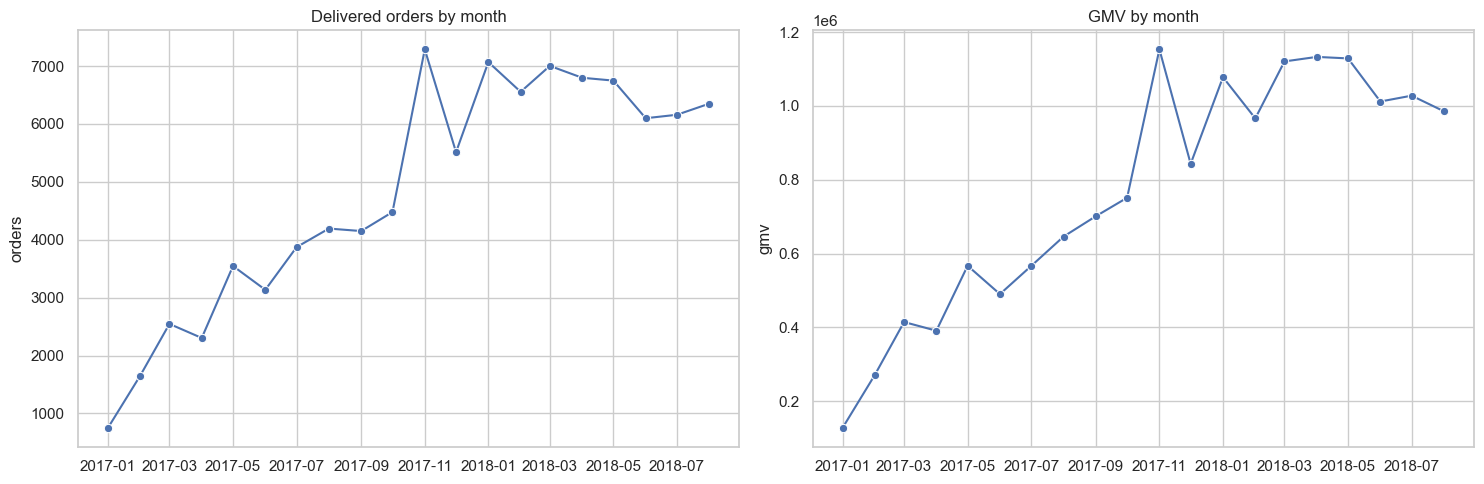

In [5]:
monthly_sales = (
    delivered.groupby("purchase_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        gmv=("gmv", "sum"),
    )
)

# Remove partial boundary months from the trend chart.
monthly_sales_complete = monthly_sales.loc[
    monthly_sales["purchase_month"].between("2017-01-01", "2018-08-01")
].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly_sales_complete, x="purchase_month", y="orders", marker="o", ax=axes[0])
sns.lineplot(data=monthly_sales_complete, x="purchase_month", y="gmv", marker="o", ax=axes[1])
axes[0].set_title("Delivered orders by month")
axes[1].set_title("GMV by month")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

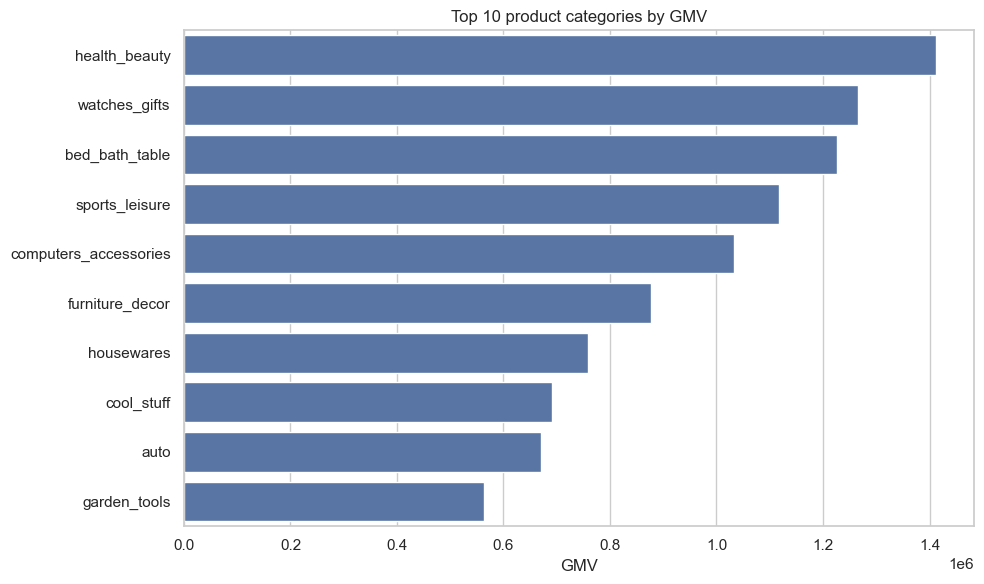

,product_category_name_english,orders,gmv
43,health_beauty,8613,1412899.75
70,watches_gifts,5478,1265646.64
7,bed_bath_table,9184,1226459.39
65,sports_leisure,7493,1117692.21
15,computers_accessories,6512,1032733.64
39,furniture_decor,6188,876877.44
49,housewares,5680,757890.31
20,cool_stuff,3530,692050.84
5,auto,3793,669810.68
42,garden_tools,3400,563327.95


In [6]:
category_sales = (
    delivered.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english", as_index=False)
    .agg(orders=("order_id", "nunique"), gmv=("gmv", "sum"))
    .sort_values("gmv", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, y="product_category_name_english", x="gmv")
plt.title("Top 10 product categories by GMV")
plt.xlabel("GMV")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_categories.png", dpi=150, bbox_inches="tight")
plt.show()

category_sales

## 5. Repeat purchases and cohort retention

In [7]:
orders_per_customer = (
    delivered.groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customer_rate = orders_per_customer.gt(1).mean()
print(f"Repeat customer rate: {repeat_customer_rate:.2%}")
print(orders_per_customer.value_counts().sort_index().head(10))

Repeat customer rate: 3.00%
order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


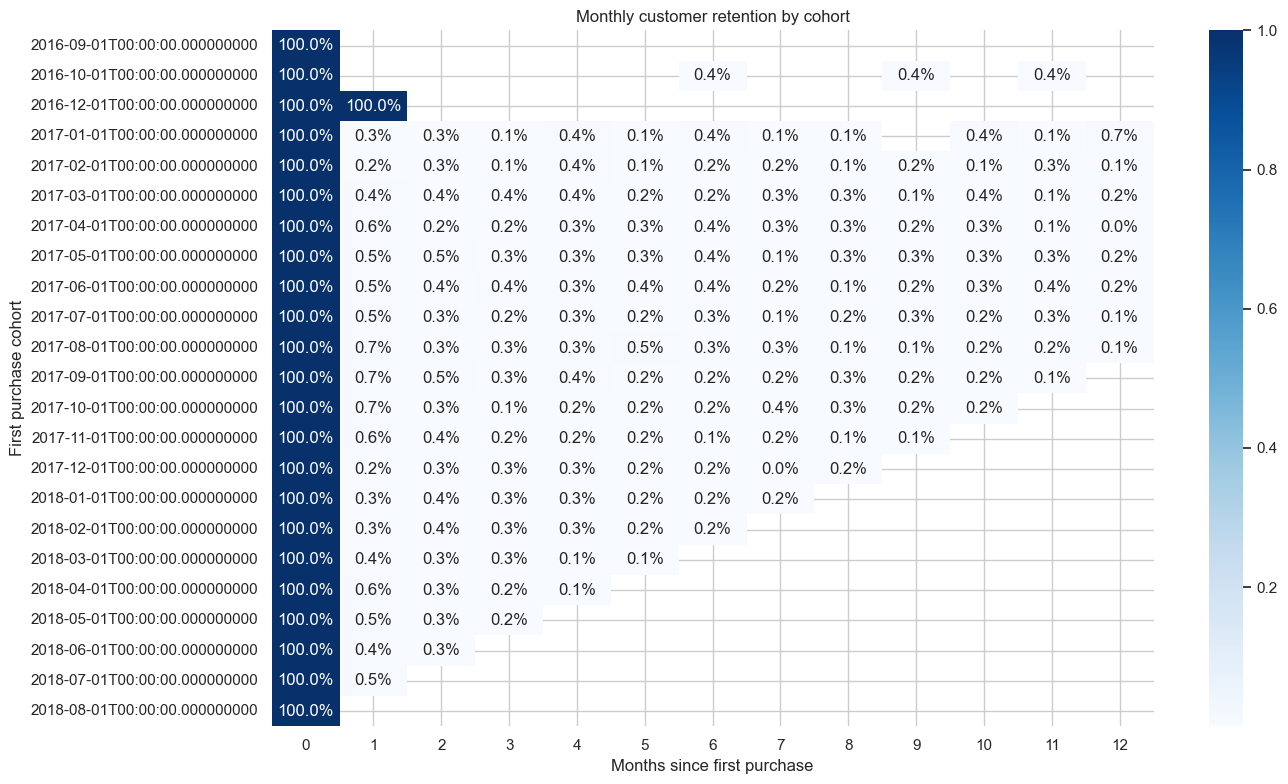

In [8]:
cohort_df = (
    delivered[
        ["customer_unique_id", "order_id", "purchase_month"]
    ]
    .dropna()
    .drop_duplicates()
)

first_orders = (
    cohort_df.groupby("customer_unique_id", as_index=False)["purchase_month"]
    .min()
    .rename(columns={"purchase_month": "cohort_month"})
)

cohort = cohort_df.merge(first_orders, on="customer_unique_id", how="left")
cohort["cohort_index"] = (
    (cohort["purchase_month"].dt.year - cohort["cohort_month"].dt.year) * 12
    + cohort["purchase_month"].dt.month
    - cohort["cohort_month"].dt.month
)

cohort_counts = (
    cohort.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index(name="active_customers")
)

cohort_sizes = (
    cohort_counts.loc[cohort_counts["cohort_index"].eq(0), ["cohort_month", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)

cohort_retention = cohort_counts.merge(cohort_sizes, on="cohort_month", how="left")
cohort_retention["retention"] = (
    cohort_retention["active_customers"] / cohort_retention["cohort_size"]
)

retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention",
)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot.iloc[:, :13], annot=True, fmt=".1%", cmap="Blues")
plt.title("Monthly customer retention by cohort")
plt.xlabel("Months since first purchase")
plt.ylabel("First purchase cohort")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** `cohort_index = 0` is the month of a customer's first purchase. Index `1` is the next month, index `2` is two months later, and so on. This aligns different calendar cohorts by customer lifetime.

## 6. RFM customer segmentation

In [9]:
snapshot_date = delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    delivered.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("gmv", "sum"),
    )
    .reset_index()
)

rfm["R"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1],
).astype(int)

# Frequency is highly concentrated at one order, so business rules are clearer than quantiles.
rfm["F"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["M"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["rfm_score"] = rfm[["R", "F", "M"]].sum(axis=1)

rfm["segment"] = np.select(
    [
        (rfm["R"] >= 4) & (rfm["F"] >= 2) & (rfm["M"] >= 4),
        (rfm["R"] >= 4) & (rfm["F"] == 1),
        (rfm["R"] <= 2) & (rfm["F"] >= 2),
        (rfm["R"] <= 2),
    ],
    ["Champions", "New customers", "At risk", "Inactive"],
    default="Regular",
)

segment_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        average_recency=("recency", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary=("monetary", "mean"),
    )
    .sort_values("customers", ascending=False)
)

segment_summary

,segment,customers,average_recency,average_frequency,average_monetary
2,Inactive,36347,394.931714,1.000000,161.786499
3,New customers,36135,90.408800,1.000000,164.317359
4,Regular,18891,218.337939,1.046318,155.696277
0,At risk,996,381.404618,2.081325,293.945522
1,Champions,989,88.738119,2.180991,371.773509


## 7. Delivery quality and reviews

In [10]:
delivery_analysis = (
    delivered[
        ["order_id", "is_late", "delay_days", "delivery_days", "review_score", "bad_review"]
    ]
    .dropna(subset=["delay_days", "review_score"])
    .copy()
)

delivery_analysis["is_late"] = delivery_analysis["is_late"].astype(bool)
delivery_analysis["bad_review"] = delivery_analysis["bad_review"].astype(int)

delivery_metrics = (
    delivery_analysis.groupby("is_late")
    .agg(
        orders=("order_id", "nunique"),
        average_review=("review_score", "mean"),
        bad_review_share=("bad_review", "mean"),
        average_delivery_days=("delivery_days", "mean"),
    )
)

delivery_metrics

,orders,average_review,bad_review_share,average_delivery_days
is_late,,,,
False,88163,4.294292,0.091875,10.877733
True,7661,2.566506,0.539877,31.378793


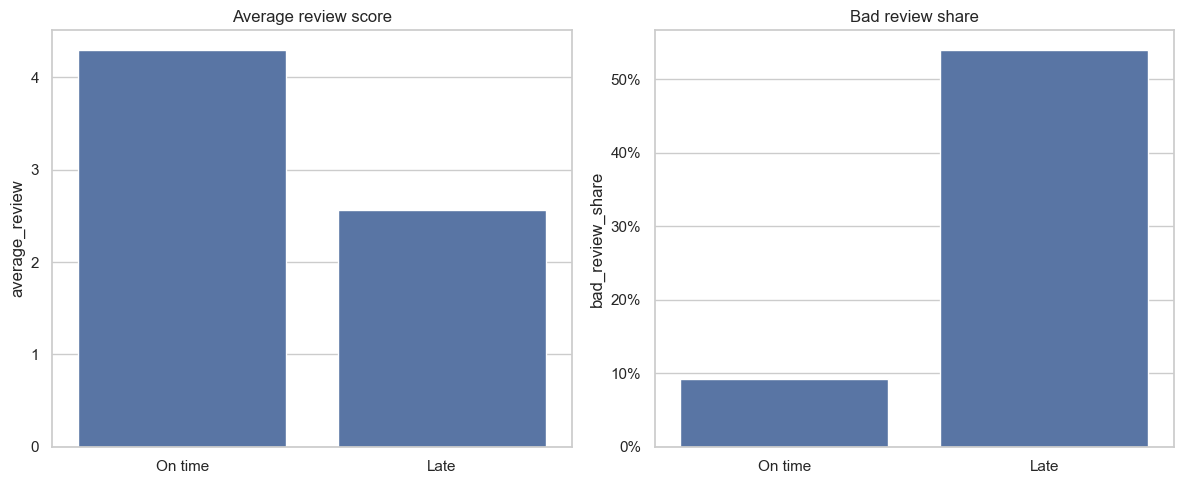

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_data = delivery_metrics.reset_index()
plot_data["delivery_status"] = plot_data["is_late"].map({False: "On time", True: "Late"})

sns.barplot(data=plot_data, x="delivery_status", y="average_review", ax=axes[0])
sns.barplot(data=plot_data, x="delivery_status", y="bad_review_share", ax=axes[1])
axes[0].set_title("Average review score")
axes[1].set_title("Bad review share")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delivery_reviews.png", dpi=150, bbox_inches="tight")
plt.show()

### Basic statistical tests

The tests below answer whether the observed differences are statistically significant:

- **Chi-square test:** association between delivery status and bad-review status.
- **Welch t-test:** difference in average review score.

These are observational data, not a randomized experiment. Statistical significance shows an association but does not prove causality.

In [12]:
contingency_table = pd.crosstab(
    delivery_analysis["is_late"],
    delivery_analysis["bad_review"],
)

chi2_stat, chi2_p_value, dof, expected = chi2_contingency(contingency_table)

late_reviews = delivery_analysis.loc[
    delivery_analysis["is_late"], "review_score"
]
on_time_reviews = delivery_analysis.loc[
    ~delivery_analysis["is_late"], "review_score"
]

t_stat, t_p_value = ttest_ind(
    late_reviews,
    on_time_reviews,
    equal_var=False,
)

statistical_results = pd.DataFrame(
    {
        "test": ["Chi-square: bad review share", "Welch t-test: average review"],
        "statistic": [chi2_stat, t_stat],
        "p_value": [chi2_p_value, t_p_value],
        "conclusion_at_5_percent": [
            "Reject H0" if chi2_p_value < 0.05 else "Do not reject H0",
            "Reject H0" if t_p_value < 0.05 else "Do not reject H0",
        ],
    }
)

statistical_results

,test,statistic,p_value,conclusion_at_5_percent
0,Chi-square: bad review share,12696.532368,0.0,Reject H0
1,Welch t-test: average review,-89.384390,0.0,Reject H0


## 8. Final conclusions and recommendations

In [13]:
summary = {
    "delivered_orders": total_orders,
    "unique_customers": unique_customers,
    "gmv": round(gmv, 2),
    "average_order_value": round(aov, 2),
    "repeat_customer_rate": round(repeat_customer_rate, 4),
    "on_time_bad_review_share": round(delivery_metrics.loc[False, "bad_review_share"], 4),
    "late_bad_review_share": round(delivery_metrics.loc[True, "bad_review_share"], 4),
    "on_time_average_review": round(delivery_metrics.loc[False, "average_review"], 2),
    "late_average_review": round(delivery_metrics.loc[True, "average_review"], 2),
}

summary

{'delivered_orders': 96478,
 'unique_customers': 93358,
 'gmv': np.float64(15419773.75),
 'average_order_value': np.float64(159.83),
 'repeat_customer_rate': np.float64(0.03),
 'on_time_bad_review_share': np.float64(0.0919),
 'late_bad_review_share': np.float64(0.5399),
 'on_time_average_review': np.float64(4.29),
 'late_average_review': np.float64(2.57)}

### Key findings

1. **Retention is the main growth limitation.** The marketplace has a very low repeat-customer rate, so growth depends heavily on acquiring new customers.
2. **Delivery quality is strongly associated with satisfaction.** Late orders have a substantially higher bad-review share and a lower average review score.
3. **The category portfolio is concentrated.** The top categories generate a meaningful share of GMV and should be monitored separately.
4. **RFM segmentation identifies actionable customer groups.** Recent one-time buyers are the largest CRM opportunity, while repeat high-value buyers should be protected.

### Business recommendations

- Launch CRM campaigns focused on a second purchase within 30–60 days.
- Monitor late-delivery share and bad-review share by category and state.
- Prioritize proactive communication for orders at risk of delay.
- Build a seller-quality dashboard using delivery, cancellation, and review metrics.

### Limitations

- Olist data are historical and observational; the analysis does not prove causality.
- GMV includes product price and freight, but does not represent marketplace profit.
- The dataset does not contain marketing costs, margins, or real experiment assignments.
- Boundary months are incomplete and excluded from the sales trend chart.